In [1]:
!pip install cirq

In [2]:
import cirq
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time

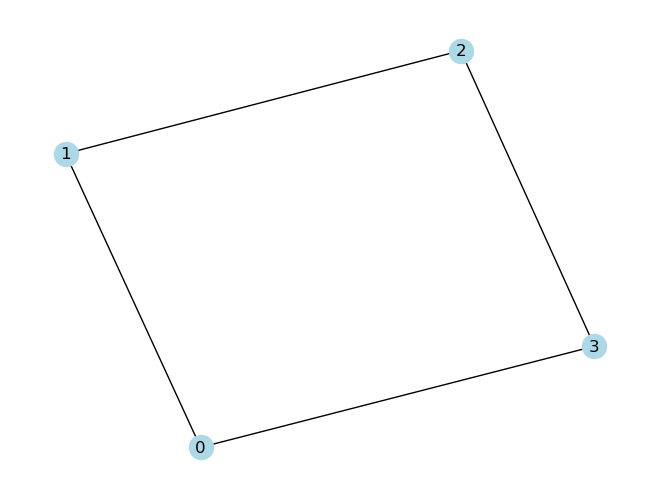

Parámetros óptimos: [1.98865825 2.66271945]
Valor final del costo: 2.931640625
Tiempo total de ejecución: 0.639202356338501 segundos


In [3]:
graph = nx.Graph([(0,1),(1,2),(2,3),(3,0)])
nx.draw(graph, with_labels=True, node_color='lightblue')
plt.show()

qubits = [cirq.GridQubit(0,i) for i in range(len(graph.nodes))]

def qaoa_circuit(params):
    gamma, beta = params
    circuit = cirq.Circuit()
    circuit.append([cirq.H(q) for q in qubits])
    for i,j in graph.edges:
        circuit.append(cirq.CNOT(qubits[i], qubits[j]))
        circuit.append(cirq.rz(2*gamma).on(qubits[j]))
        circuit.append(cirq.CNOT(qubits[i], qubits[j]))
    for q in qubits:
        circuit.append(cirq.rx(2*beta).on(q))
    circuit.append([cirq.measure(q) for q in qubits])
    return circuit

simulator = cirq.Simulator()

def cost_function(params):
    circuit = qaoa_circuit(params)
    result = simulator.run(circuit, repetitions=1024)
    cost = 0
    for i in range(1024):
        bits = [int(result.measurements[str(q)][i][0]) for q in qubits]  # <- fix
        z = np.array([1 if b==0 else -1 for b in bits])
        s = sum(0.5*(1 - z[i]*z[j]) for i,j in graph.edges)
        cost += s
    return -cost/1024

np.random.seed(42)
params0 = np.random.uniform(0, np.pi, 2)
start = time.time()

result = minimize(cost_function, params0, method='COBYLA')

end = time.time()

print("Parámetros óptimos:", result.x)
print("Valor final del costo:", -result.fun)
print("Tiempo total de ejecución:", end - start, "segundos")